# FLARE Pantanal Fire Event Database  - Dataset Exploration Demo (2024)

**Author**: Tianjiao Pu (TJ)  
**Current Affiliation**: High Meadows Environmental Institute, Princeton University  
**Project**: A Song of Water and Fire — Berkeley FLARE  

**Last updated**: March 2026  

---

## Overview

This notebook provides a structured walkthrough of the FLARE wildfire event database, an event-centric framework for reconstructing wildfire dynamics from satellite-derived burned area data.

The workflow is organized as follows:

- **Step 1** — Load and initialize the dataset  
- **Step 2** — Explore dataset structure and statistics  
- **Step 3** — Identify and map the largest fire events  
- **Step 4** — Analyze a representative large fire event in detail:
  - spatial evolution
  - lineage structure (parent–child transitions)
  - ignition patterns  

---

This notebook is designed to be:
- **user-friendly** for interactive exploration  
- **reproducible** for research workflows  
- **interpretable** for understanding event-based wildfire dynamics  

---

## Step 1 - Load a Sample Database

Each yearly database contains:

• fire objects (daily burned clusters)  
• object transitions (parent–child links between days)  
• constructed fire events (lineage-connected components)  
• spatial and project metadata  

In this section we load the sample database and inspect its structure.

In [1]:
import sqlite3
import pandas as pd
from pathlib import Path

# --- user config ---
year = 2024    # defined year of interest

# --- load database ---
db_path = f"data/pantanal_fire_events_{year}.db"
conn = sqlite3.connect(db_path)

# --- list database tables ---
tables = pd.read_sql("""
SELECT name
FROM sqlite_master
WHERE type='table'
ORDER BY name
""", conn)

print("\n=== Database Tables ===")
print(tables.to_string(index=False))

# --- load metadata ---
metadata_pj = pd.read_sql("SELECT * FROM project_metadata", conn)
metadata_sp = pd.read_sql("SELECT * FROM spatial_metadata", conn)

print("\n=== Project Metadata ===")
print(metadata_pj.to_string(index=False, justify='center'))

print("\n=== Spatial Metadata ===")
meta_sp = metadata_sp.drop(columns=["projection_wkt"], errors="ignore").T
meta_sp.columns = ["value"]
print(meta_sp)


=== Database Tables ===
            name
      event_days
     fire_events
    fire_objects
fire_transitions
project_metadata
spatial_metadata

=== Project Metadata ===
         field                                                     content                                          
                 project          A Song of Water and Fire - Berkeley FLARE (Fire Lineage and Reconstruction Engine)
                  author                              Tianjiao Pu, Robinson Negrón-Juárez, and Cynthia Gerlein-Safdi
                   email                                              putianjiao@berkeley.edu, cgerlein@berkeley.edu
                     lab                                                                        Water and Carbon Lab
             institution                                                          University of California, Berkeley
                    link                                        https://sites.google.com/berkeley.edu/gerlein-safdi/
           

## Step 2. Dataset Overview

We first summarize the key characteristics of the wildfire activity recorded in the database.

### Basic dataset statistics
Inspect the overall size of the wildfire event dataset.
This includes the total number of reconstructed fire events
and the number of object transitions linking fire objects across days.

In [2]:
n_events = pd.read_sql("SELECT COUNT(*) FROM fire_events", conn).iloc[0,0]
n_transitions = pd.read_sql("SELECT COUNT(*) FROM fire_transitions", conn).iloc[0,0]

print(f"Total fire events        : {n_events:,}")
print(f"Total object transitions : {n_transitions:,}")

Total fire events        : 1,546
Total object transitions : 85,017


### Event size and duration statistics
Each fire event is composed of temporally linked fire objects.
Here we summarize key event characteristics:
  - mean event duration (days)
  - mean event size
  - largest event in the dataset

NOTE:
Event size is measured in number of pixels.
Each pixel represents ~500 m by 500 m  resolution burned area.

In [3]:
event_stats = pd.read_sql("""
SELECT
    AVG(duration_days) AS mean_duration_days,
    MAX(peak_object_pixels) AS largest_event_pixels,
    AVG(peak_object_pixels) AS mean_event_pixels
FROM fire_events
""", conn)

event_stats

,mean_duration_days,largest_event_pixels,mean_event_pixels
0,43.756792,70572,210.31436


### Preview of the largest fire events
We retrieve the largest fire events ranked by their peak daily size.
These events will be used later for visualization.

In [4]:
top_events = pd.read_sql("""
SELECT
    lineage_id,
    peak_object_pixels,
    duration_days,
    n_objects
FROM fire_events
ORDER BY peak_object_pixels DESC
LIMIT 10
""", conn)

top_events

,lineage_id,peak_object_pixels,duration_days,n_objects
0,616,70572,156,16168441
1,634,36834,153,6906384
2,493,15442,177,1166400
3,396,14262,170,1425636
4,743,12270,92,151321
5,878,9073,105,385641
6,800,9060,108,72900
7,640,6402,118,70225
8,752,5756,61,12100
9,702,5661,136,736164


## Step 3. Largest Fire Events on Map
In this section, we highlight the largest wildfire events reconstructed by FLARE.

The background map shows the spatial footprint of all fire activity in the 2024 database.
The five highlighted boxes mark the largest independent fire events, ranked by the
size of their largest single-day fire object (`peak_object_pixels`).

This view provides a quick overview of where the dominant fire events occurred
within the study region.

### Retrieve top five events and reference data

In [5]:
### --- load data --- 
top5 = pd.read_sql("""
SELECT
    lineage_id,
    peak_object_pixels,
    duration_days,
    n_objects
FROM fire_events
ORDER BY peak_object_pixels DESC
LIMIT 5
""", conn)

top5 = top5.reset_index(drop=True)
top5["rank"] = top5.index + 1

# load bounding boxes for the top wildfire events by aggregating all fire objects within each lineage. 
boxes = pd.read_sql(f"""
SELECT
    lineage_id,
    MIN(bbox_x_min) AS x0,
    MIN(bbox_y_min) AS y0,
    MAX(bbox_x_max) AS x1,
    MAX(bbox_y_max) AS y1
FROM fire_objects
WHERE lineage_id IN ({",".join(map(str, top5.lineage_id.tolist()))})
GROUP BY lineage_id
""", conn)

boxes = top5[["lineage_id", "rank", "peak_object_pixels"]].merge(boxes, on="lineage_id", how="left")
boxes = boxes.sort_values("rank")

# load background data - all objects through the year
all_objects = pd.read_sql("""
SELECT
    bbox_y_min, bbox_x_min,
    shape_h, shape_w,
    mask_blob
FROM fire_objects
""", conn)

In [6]:
import zlib
import numpy as np
# --- build background map ---
shape = (1792, 1671)
background = np.zeros(shape, dtype=np.uint16)
for _, r in all_objects.iterrows():
    y0 = int(r["bbox_y_min"])
    x0 = int(r["bbox_x_min"])
    h = int(r["shape_h"])
    w = int(r["shape_w"])
    mask = np.frombuffer(zlib.decompress(r["mask_blob"]), dtype=np.uint8).reshape((h, w))
    background[y0:y0+h, x0:x0+w] += mask.astype(np.uint16)


### --- build event map ---
event_maps = {}
for lineage_id in top5["lineage_id"]:
    event_objects = pd.read_sql(f"""
    SELECT
        bbox_y_min, bbox_x_min,
        shape_h, shape_w,
        mask_blob
    FROM fire_objects
    WHERE lineage_id = {lineage_id}
    """, conn)
    event_map = np.zeros(shape, dtype=np.uint16)
    for _, r in event_objects.iterrows():
        yy0 = int(r["bbox_y_min"])
        xx0 = int(r["bbox_x_min"])
        h = int(r["shape_h"])
        w = int(r["shape_w"])
        mask = np.frombuffer(zlib.decompress(r["mask_blob"]), dtype=np.uint8).reshape((h, w))
        event_map[yy0:yy0+h, xx0:xx0+w] += mask.astype(np.uint16)
    event_maps[lineage_id] = event_map

Plot annual burned severity with top-event overlays
- Gray = annual burned severity of all fire activity
- Red = burned severity of each highlighted event only

C:\Users\putia\AppData\Local\Temp\ipykernel_16900\465624395.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


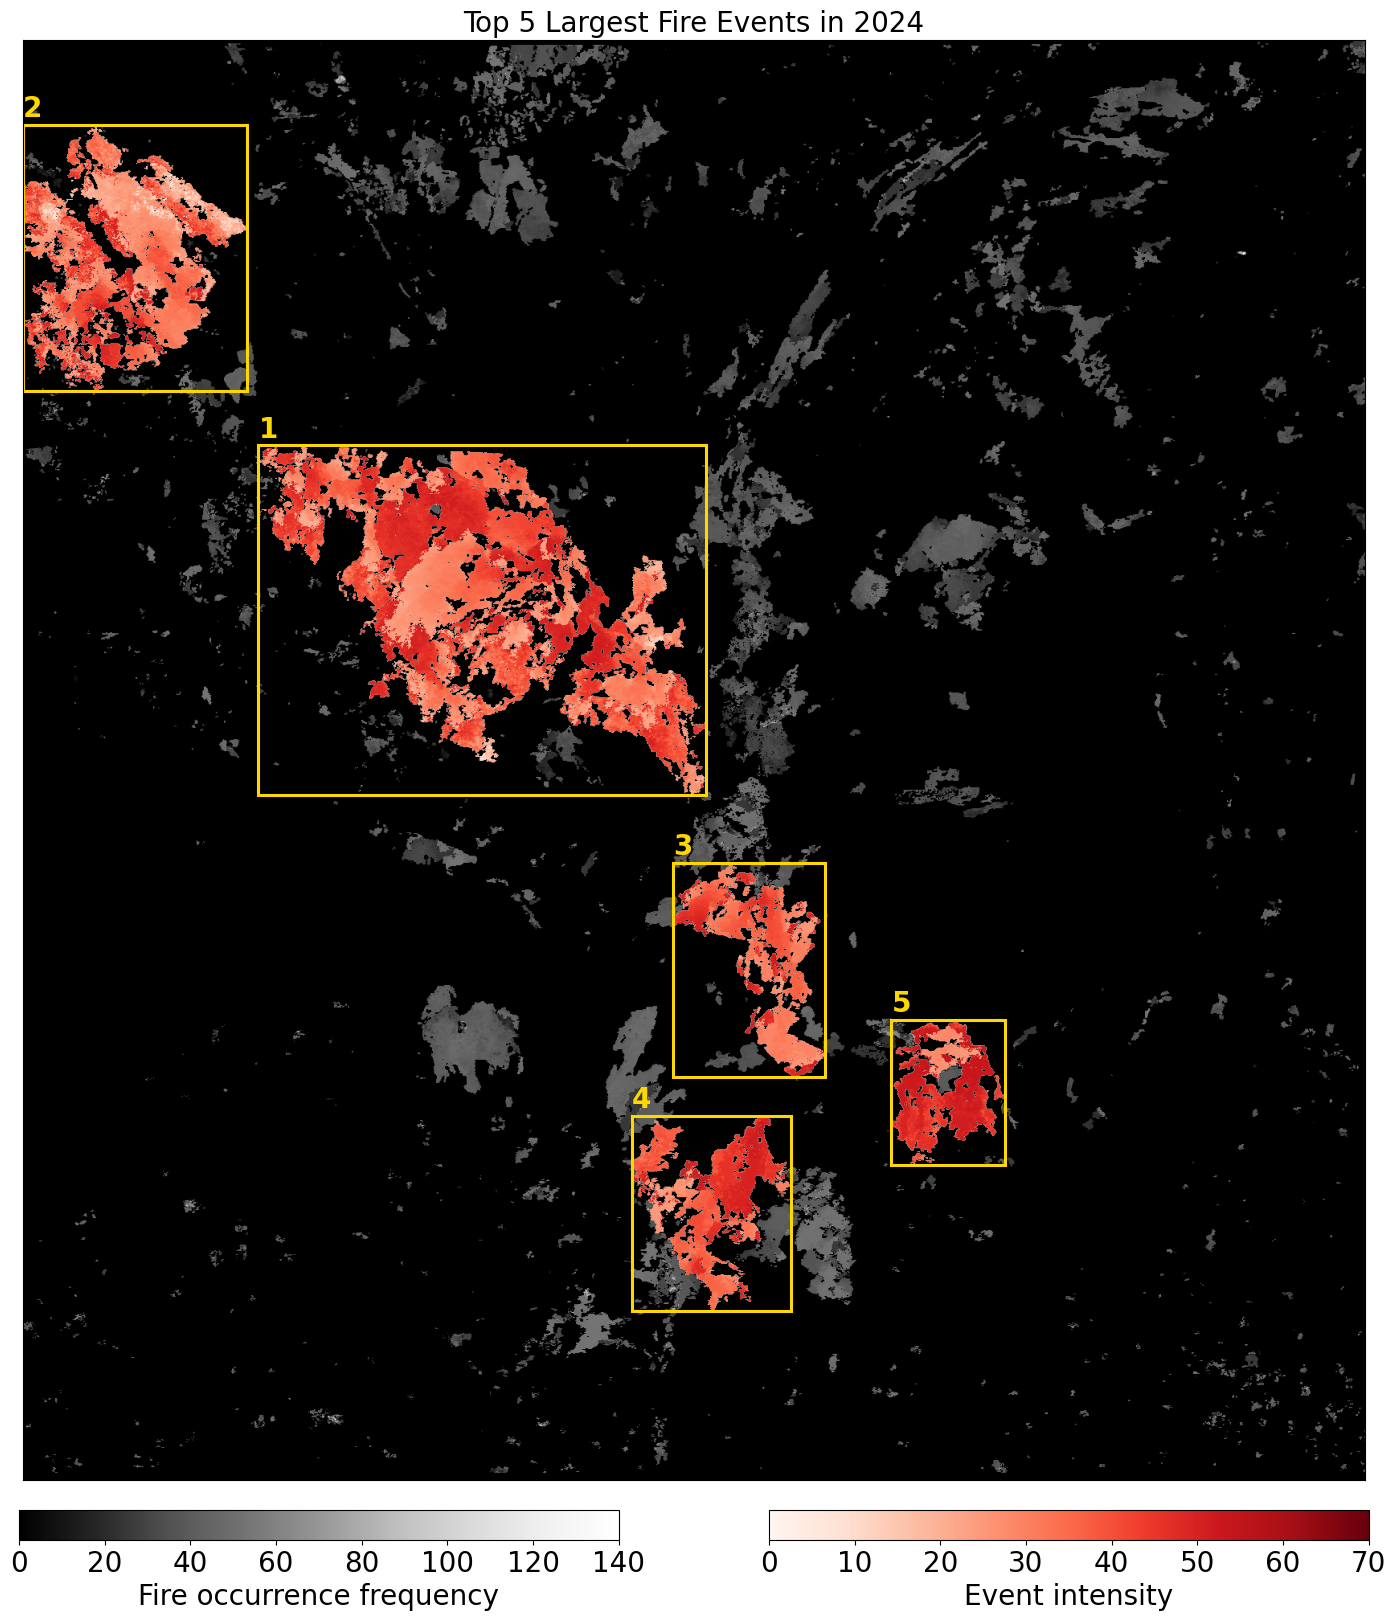

In [7]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle

reds = plt.cm.Reds(np.linspace(0, 1, 256))
reds[0, -1] = 0.0  # Set alpha channel to 0 (transparent)
white_to_reds = mcolors.ListedColormap(reds)

fig, ax = plt.subplots(figsize=(15, 15))
ax.set_facecolor("black")
bg_im = ax.imshow(background, cmap="Greys_r", origin="lower",vmin=0,vmax=140)
for _, row in boxes.iterrows():
    lineage_id = int(row["lineage_id"])
    rank = int(row["rank"])
    x0 = int(row["x0"])
    y0 = int(row["y0"])
    x1 = int(row["x1"])
    y1 = int(row["y1"])

    # local patch from this event only
    event_patch = event_maps[lineage_id][y0:y1, x0:x1]
    event_patch = np.ma.masked_where(event_patch == 0, event_patch)

    # put patch back in the same pixel coordinates
    overlay = np.full(shape, np.nan)
    overlay[y0:y1, x0:x1] = event_patch

    sm = ax.imshow(overlay, cmap=white_to_reds, origin="lower",vmin=0,vmax=70)
    rect = Rectangle((x0, y0), x1-x0, y1-y0, fill=False, edgecolor="gold", linewidth=2.2)
    ax.add_patch(rect)
    ax.text(x0, y1+10, f"{rank}", color="gold", fontsize=20, weight="bold")
    

cax1 = fig.add_axes([0.05, -0.03, 0.4, 0.02])  # [left, bottom, width, height]
cax2 = fig.add_axes([0.55, -0.03, 0.4, 0.02])

# background colorbar
cbar1 = fig.colorbar(bg_im, cax=cax1, orientation="horizontal")
cbar1.set_label("Fire occurrence frequency", fontsize=20)
cbar1.ax.tick_params(labelsize=20)

# overlay colorbar
sm = cm.ScalarMappable(norm=mcolors.Normalize(vmin=0, vmax=70), cmap=white_to_reds); sm.set_array([])
cbar2 = fig.colorbar(sm, cax=cax2, orientation="horizontal")
cbar2.set_label("Event intensity", fontsize=20)
cbar2.ax.tick_params(labelsize=20)

ax.set_title(f"Top 5 Largest Fire Events in {year}", fontsize=20)
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.show()

## Step 4. Largest Fire Event - Zoom in
In this section, we visualize the temporal evolution of the largest fire event.

We first identify the event with the largest single-day fire object, then
retrieve all objects belonging to this event (i.e., its full lineage).

To provide an interpretable overview, we sample evenly spaced days across
the event lifetime and visualize the spatial configuration of fire objects
at each stage.

Each panel shows:
- fire object masks (red)
- individual object bounding boxes (outlined)

### Load data

#### Identify the largest fire event
The largest event is defined as the lineage containing the
largest single-day fire object.

In [8]:
top_event = pd.read_sql("""
SELECT *
FROM fire_events
ORDER BY peak_object_pixels DESC
LIMIT 1
""", conn)

lineage_id = int(top_event.iloc[0]["lineage_id"])
print("Top event lineage_id:", lineage_id)

Top event lineage_id: 616


#### Load all objects belonging to this event

In [9]:
objs = pd.read_sql(f"""
SELECT
    doy, orig_id,
    bbox_y_min, bbox_x_min, bbox_y_max, bbox_x_max,
    shape_h, shape_w, area_pixels, mask_blob
FROM fire_objects
WHERE lineage_id = {lineage_id}
ORDER BY doy, orig_id
""", conn)

# --- Event summary --- 
doy_min = int(objs["doy"].min())
doy_max = int(objs["doy"].max())
n_days = objs["doy"].nunique()
n_objects = len(objs)

# peak object (largest single-day object)
peak_idx = objs["area_pixels"].idxmax()
peak_doy = int(objs.loc[peak_idx, "doy"])
peak_size = int(objs.loc[peak_idx, "area_pixels"])

print("--------------------------------------------------")
print(f"Lineage ID        : {lineage_id}")
print(f"Time span (DOY)   : {doy_min+1:03d} → {doy_max+1:03d}")
print(f"Active days       : {n_days}")
print(f"Total objects     : {n_objects}")
print(f"Peak object (DOY) : {peak_doy+1:03d}")
print(f"Peak size (pixel) : {peak_size:,}")
print("--------------------------------------------------")

--------------------------------------------------
Lineage ID        : 616
Time span (DOY)   : 173 → 328
Active days       : 156
Total objects     : 4021
Peak object (DOY) : 261
Peak size (pixel) : 70,572
--------------------------------------------------


#### Sample days across the event lifetime
We select evenly spaced days to summarize the event trajectory.

In [10]:
sample_cases = 25 
days_all = sorted(objs["doy"].unique())
n_panels = min(sample_cases, len(days_all))
sample_idx = np.linspace(0, len(days_all)-1, n_panels).round().astype(int)
sample_days = [days_all[i] for i in sample_idx]

### View Event evolution
For each sampled day:
  - build a binary map of all fire objects in the event
  - add individual object bounding boxes

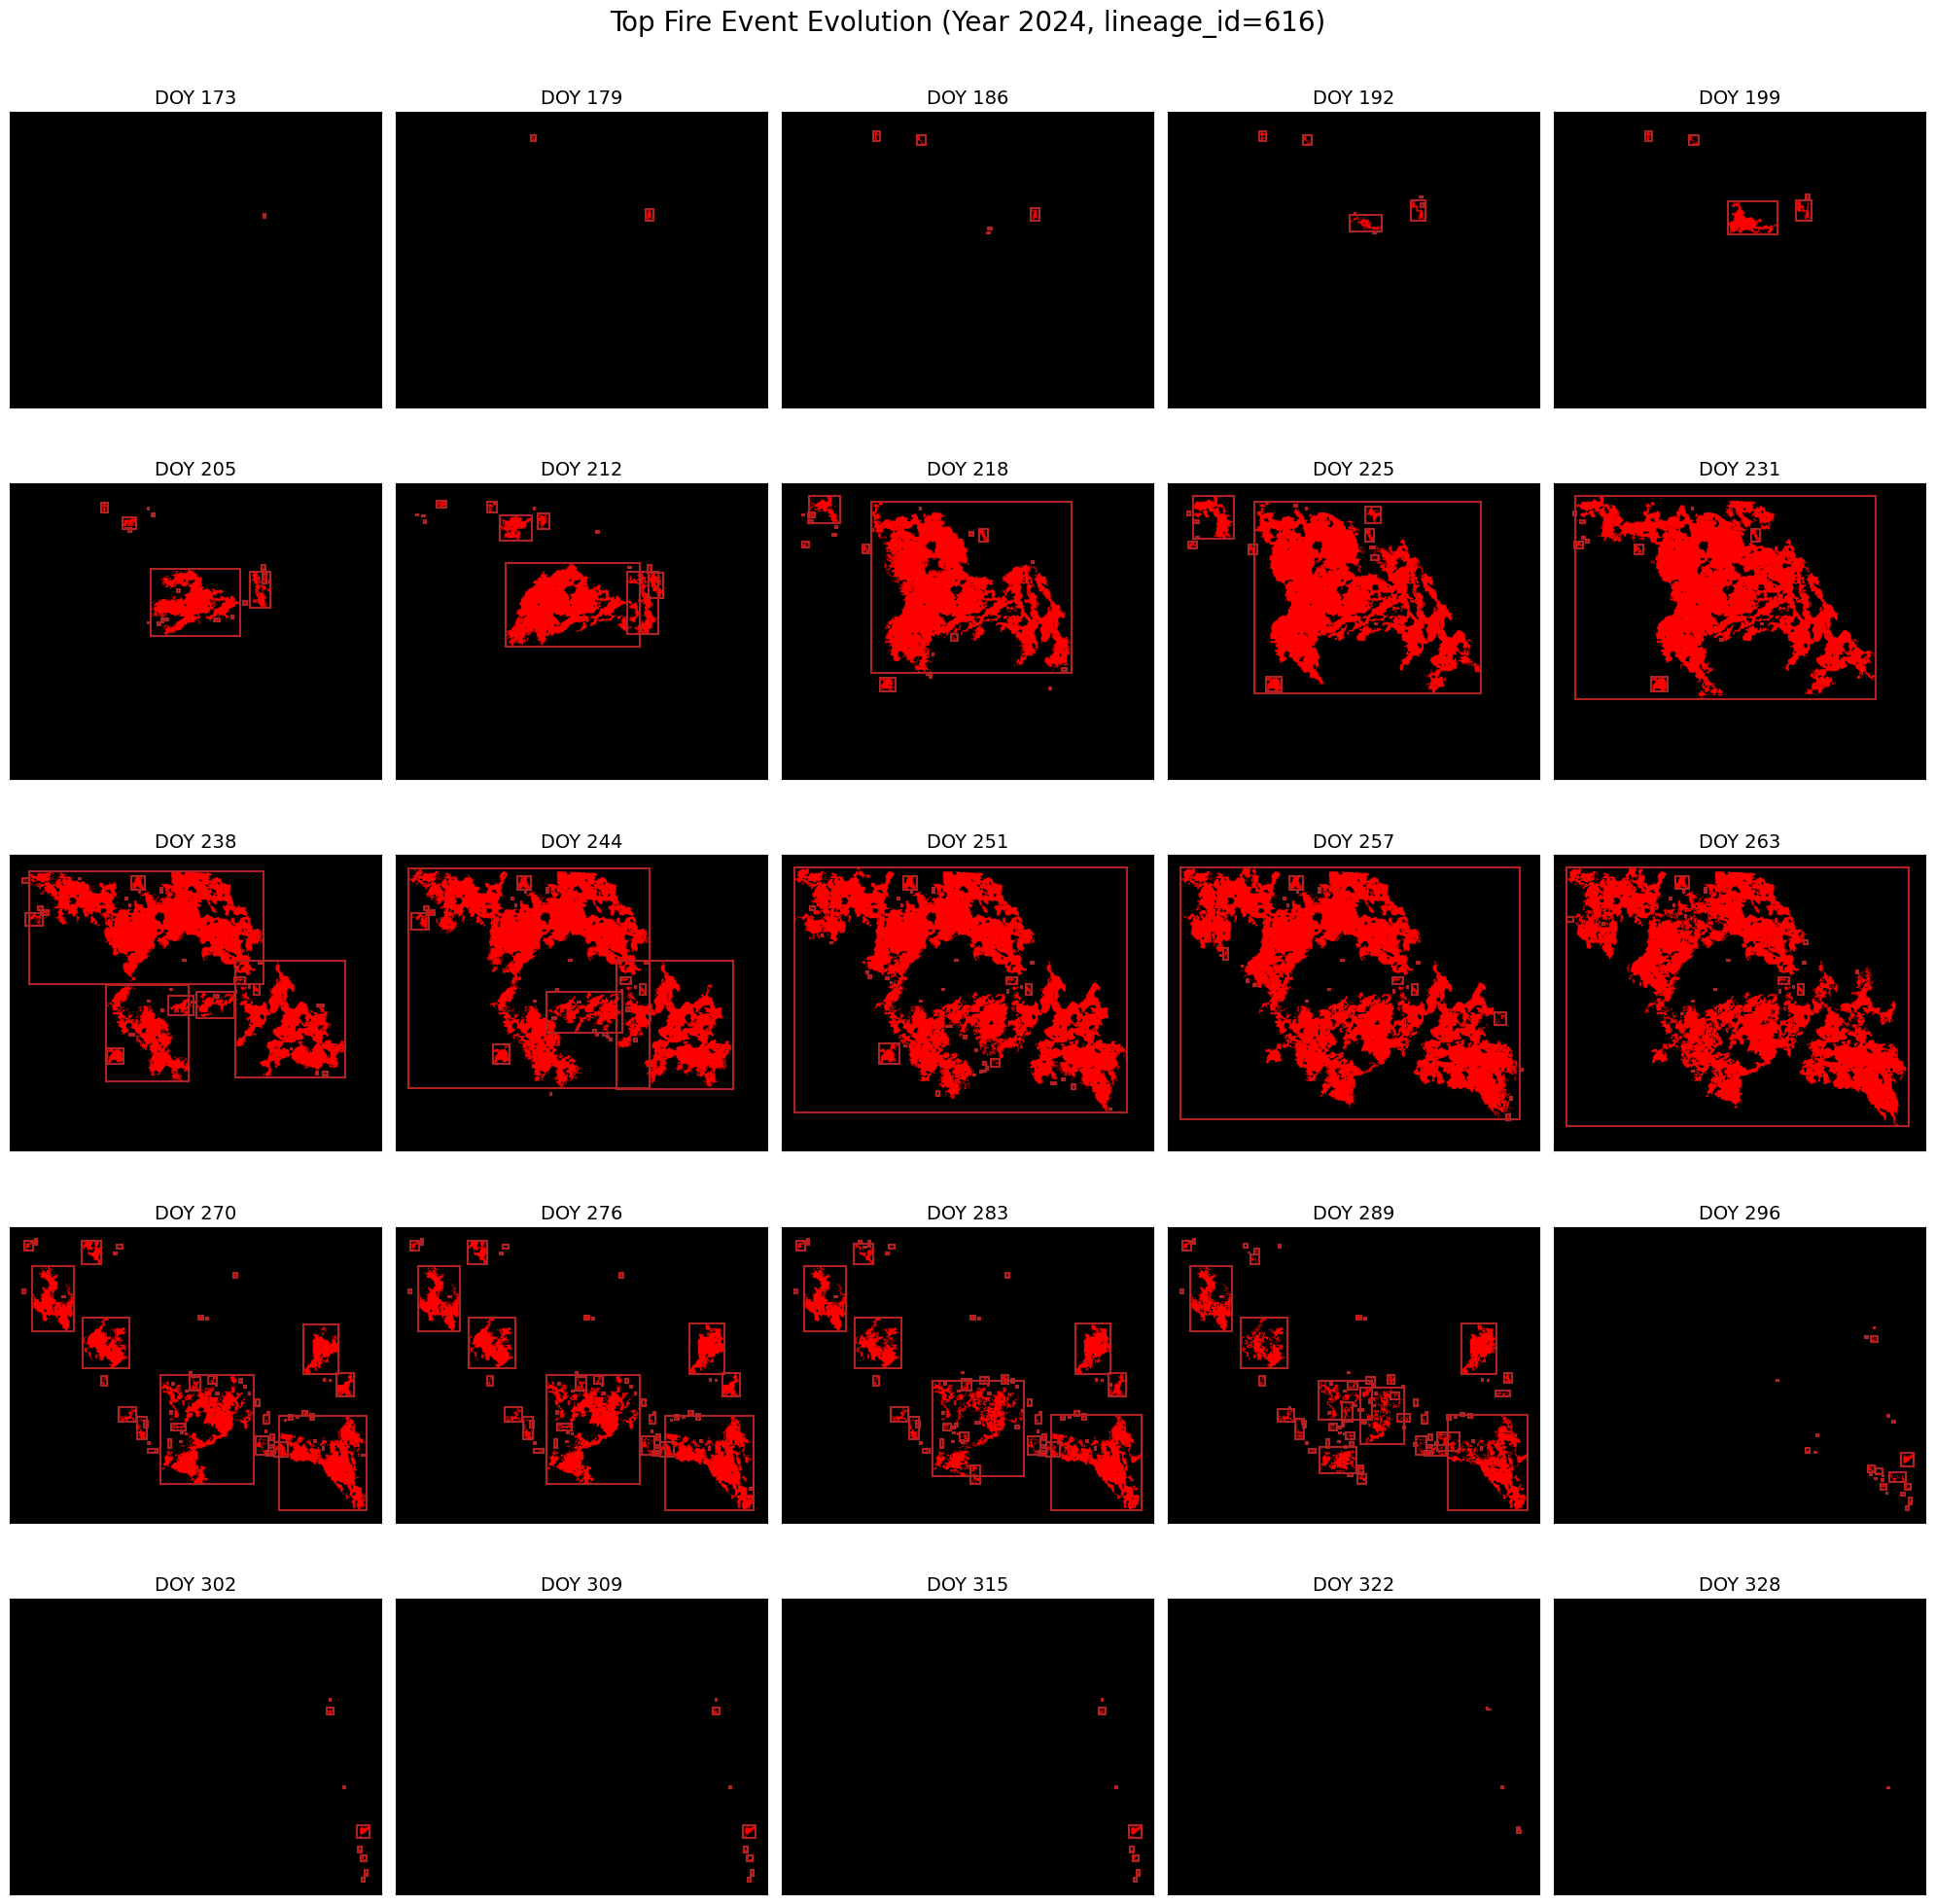

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.colors as mcolors
import zlib

# --- figure settings ---
fire_cmap = mcolors.ListedColormap(["black", "red"])
ncols_plot = 5
nrows_plot = int(np.ceil(len(sample_days) / ncols_plot))

# add space at bounds for visual clarity
pad = 20
y0 = int(objs["bbox_y_min"].min())-pad
x0 = int(objs["bbox_x_min"].min())-pad
y1 = int(objs["bbox_y_max"].max())+pad
x1 = int(objs["bbox_x_max"].max())+pad

fig, axes = plt.subplots(nrows_plot, ncols_plot, figsize=(4*ncols_plot, 4*nrows_plot))
axes = np.array(axes).reshape(-1)

for ax, doy in zip(axes, sample_days):
    ax.set_facecolor("black")
    day_df = objs[objs["doy"] == doy]
    day_map = np.zeros((y1-y0, x1-x0), dtype=np.uint8)

    # --- build daily fire map (merge all objects) ---
    for _, r in day_df.iterrows():
        yy0, xx0 = int(r["bbox_y_min"]), int(r["bbox_x_min"])
        yy1, xx1 = int(r["bbox_y_max"]), int(r["bbox_x_max"])
        h, w = int(r["shape_h"]), int(r["shape_w"])
        mask = np.frombuffer(zlib.decompress(r["mask_blob"]), dtype=np.uint8).reshape((h, w))

        # combine objects using max (logical OR)
        day_map[yy0-y0:yy1-y0, xx0-x0:xx1-x0] = np.maximum(day_map[yy0-y0:yy1-y0, xx0-x0:xx1-x0],mask)

    # --- plot fire mask ---
    ax.imshow(day_map, cmap=fire_cmap, origin="lower", vmin=0, vmax=1)

    # --- draw object bounding boxes ---
    for _, r in day_df.iterrows():
        yy0, xx0 = int(r["bbox_y_min"]), int(r["bbox_x_min"])
        yy1, xx1 = int(r["bbox_y_max"]), int(r["bbox_x_max"])
        rect = Rectangle((xx0-x0, yy0-y0), xx1-xx0, yy1-yy0,
                         fill=False, edgecolor="firebrick", linewidth=1.5)
        ax.add_patch(rect)

    # --- style ---
    ax.set_title(f"DOY {doy+1:03d}", fontsize=14)
    ax.set_xticks([])
    ax.set_yticks([])

# remove unused panels
for ax in axes[len(sample_days):]:
    ax.axis("off")

fig.suptitle(f"Top Fire Event Evolution (Year {year}, lineage_id={lineage_id})", fontsize=20,y=1)
plt.tight_layout()
plt.show()

### View Event lineage structure
In addition to the spatial evolution panels, we can also represent the same fire event as a lineage flow diagram.

Here:
- each node represents one fire object at one day
- each link represents a parent–child transition between consecutive days
- node labels show the day, object ID, and object size
- link width is approximated using the parent object size

This view highlights continuation, splitting, and merging within the event.

#### search nodes

In [12]:
# --- use the top-ranked fire event identified earlier.
top_event = pd.read_sql("""
SELECT *
FROM fire_events
ORDER BY peak_object_pixels DESC
LIMIT 1
""", conn)

lineage_id = int(top_event.iloc[0]["lineage_id"])
print("Top event lineage_id:", lineage_id)

# --- Each object will become one Sankey node.
nodes_df = pd.read_sql(f"""
SELECT uid, doy, orig_id, area_pixels
FROM fire_objects
WHERE lineage_id = {lineage_id}
ORDER BY doy, orig_id
""", conn)

# --- Create node IDs and labels for Plotly
# Plotly Sankey expects nodes to be indexed as 0, 1, 2, ...
mapping = {uid: i for i, uid in enumerate(nodes_df["uid"])}

node_labels = [
    f"D{int(r.doy)+1}:ID{int(r.orig_id)}<br>{int(r.area_pixels):,} px"
    for r in nodes_df.itertuples()
]

print("Number of nodes:", len(node_labels))

Top event lineage_id: 616
Number of nodes: 4021


#### Load parent–child transitions for this event

In [15]:
# Each transition will become one Sankey link.
# Link width is approximated here using the parent object size.

links_df = pd.read_sql(f"""
SELECT t.parent_uid, t.child_uid, p.area_pixels as value
FROM fire_transitions t
JOIN fire_objects p ON t.parent_uid = p.uid
JOIN fire_objects c ON t.child_uid = c.uid
WHERE p.lineage_id = {lineage_id} AND c.lineage_id = {lineage_id}
""", conn)

print("Number of links:", len(links_df))

Number of links: 4028


#### Build the Sankey diagram

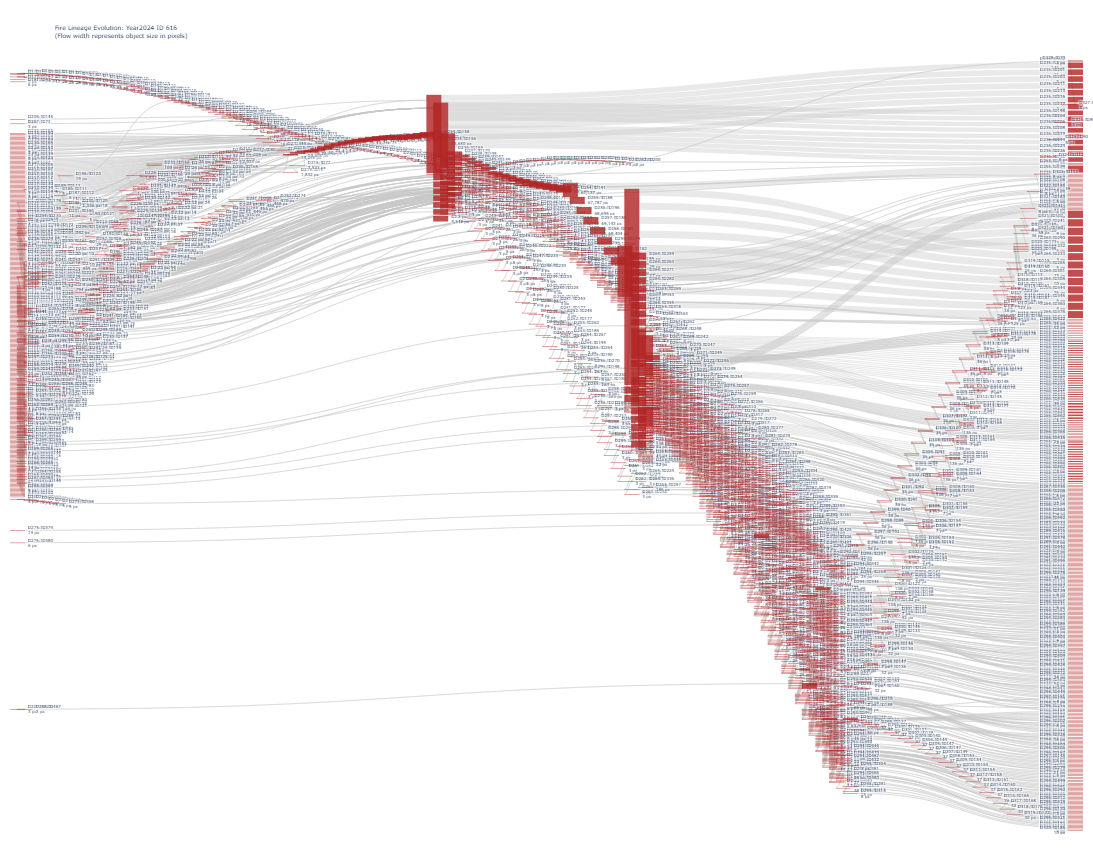

Sankey diagram generated: fire_sankey_year2024_lineageid_616.html


In [16]:
import plotly.graph_objects as go
import plotly.offline as pyo

# Nodes = fire objects
# Links = parent-child transitions

fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=20,
        thickness=15,
        line=dict(color="black", width=0),
        label=node_labels,
        color="rgba(178, 34, 34, 0.8)"  # Firebrick color
    ),
    link=dict(
        source=links_df["parent_uid"].map(mapping).tolist(),
        target=links_df["child_uid"].map(mapping).tolist(),
        value=links_df["value"].tolist(),
        color="rgba(200, 200, 200, 0.4)" # Light grey links
    )
)])

fig.update_layout(
    title_text=f"Fire Lineage Evolution: Year{year} ID {lineage_id}<br>(Flow width represents object size in pixels)",
    font_size=4,
    height=850,
    margin=dict(t=60, b=20, l=10, r=10)
)

fig.show()

output_file = f"fire_sankey_year{year}_lineageid_{lineage_id}.html"
pyo.plot(fig, filename=output_file, auto_open=True)

print("Sankey diagram generated:", output_file)

### View Ignition
In this section, we examine the ignition structure of the largest fire event.

Within the FLARE database, ignition objects are defined as fire objects with
no parent object in the event lineage.

We first retrieve all ignition objects associated with the top-ranked event,
then visualize where they are located relative to the full event footprint.

In [17]:
ign = pd.read_sql(f"""
SELECT
    o.doy, o.orig_id,
    o.bbox_y_min, o.bbox_x_min, o.bbox_y_max, o.bbox_x_max,
    o.shape_h, o.shape_w, o.area_pixels, o.mask_blob
FROM fire_objects o
LEFT JOIN fire_transitions t ON o.uid = t.child_uid
WHERE o.lineage_id = {lineage_id}
AND t.child_uid IS NULL
ORDER BY o.doy, o.orig_id
""", conn)

print("Number of ignition objects:", len(ign))
ign[["doy", "orig_id", "area_pixels"]]

Number of ignition objects: 300


,doy,orig_id,area_pixels
0,172,113,3
1,172,115,3
2,173,105,3
3,176,78,3
4,180,93,6
...,...,...,...
295,267,369,9
296,268,265,7
297,274,374,14
298,275,380,6


We construct an event-centered pixel map by aggregating all fire objects within a cropped spatial window. 

Each pixel is assigned the first day (DOY) on which it becomes active in the event, producing a burned-date map that captures the temporal expansion of the fire.

In parallel, ignition objects are rasterized into a binary ignition map using their original shapes, enabling direct comparison between event origins and subsequent spread.

In [18]:
# --- Define a cropped window around the full event
import numpy as np
import zlib
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# This crop is used for all event-level maps in pixel space.
crop_y0 = int(objs["bbox_y_min"].min())
crop_x0 = int(objs["bbox_x_min"].min())
crop_y1 = int(objs["bbox_y_max"].max())
crop_x1 = int(objs["bbox_x_max"].max())

pad = 20
crop_y0 = max(0, crop_y0 - pad)
crop_x0 = max(0, crop_x0 - pad)
crop_y1 = min(int(metadata_sp.iloc[0]["grid_height"]), crop_y1 + pad)
crop_x1 = min(int(metadata_sp.iloc[0]["grid_width"]), crop_x1 + pad)

# --- build burned date component 
burn_date = np.full((crop_y1-crop_y0, crop_x1-crop_x0), np.nan)
for _, r in objs.iterrows():

    yy0, xx0 = int(r["bbox_y_min"]), int(r["bbox_x_min"])
    yy1, xx1 = int(r["bbox_y_max"]), int(r["bbox_x_max"])
    h, w = int(r["shape_h"]), int(r["shape_w"])
    doy = int(r["doy"]) + 1

    mask = np.frombuffer(zlib.decompress(r["mask_blob"]), dtype=np.uint8).reshape((h, w)).astype(bool)

    sub = burn_date[yy0-crop_y0:yy1-crop_y0, xx0-crop_x0:xx1-crop_x0]
    sub[np.isnan(sub) & mask] = doy

# --- build ignition component 
ign_map = np.zeros((crop_y1-crop_y0, crop_x1-crop_x0), dtype=np.uint8)
for _, r in ign.iterrows():
    yy0, xx0 = int(r["bbox_y_min"]), int(r["bbox_x_min"])
    yy1, xx1 = int(r["bbox_y_max"]), int(r["bbox_x_max"])
    h, w = int(r["shape_h"]), int(r["shape_w"])

    ign_mask = np.frombuffer(zlib.decompress(r["mask_blob"]), dtype=np.uint8).reshape((h, w)).astype(bool)

    ign_map[yy0-crop_y0:yy1-crop_y0, xx0-crop_x0:xx1-crop_x0] = np.maximum(
        ign_map[yy0-crop_y0:yy1-crop_y0, xx0-crop_x0:xx1-crop_x0],
        ign_mask.astype(np.uint8)
    )

The background map shows the first active day (DOY) of each pixel within the event, illustrating the temporal expansion of the fire. Ignition objects are overlaid using their true shapes (cyan), highlighting where the event originates relative to its subsequent spread.

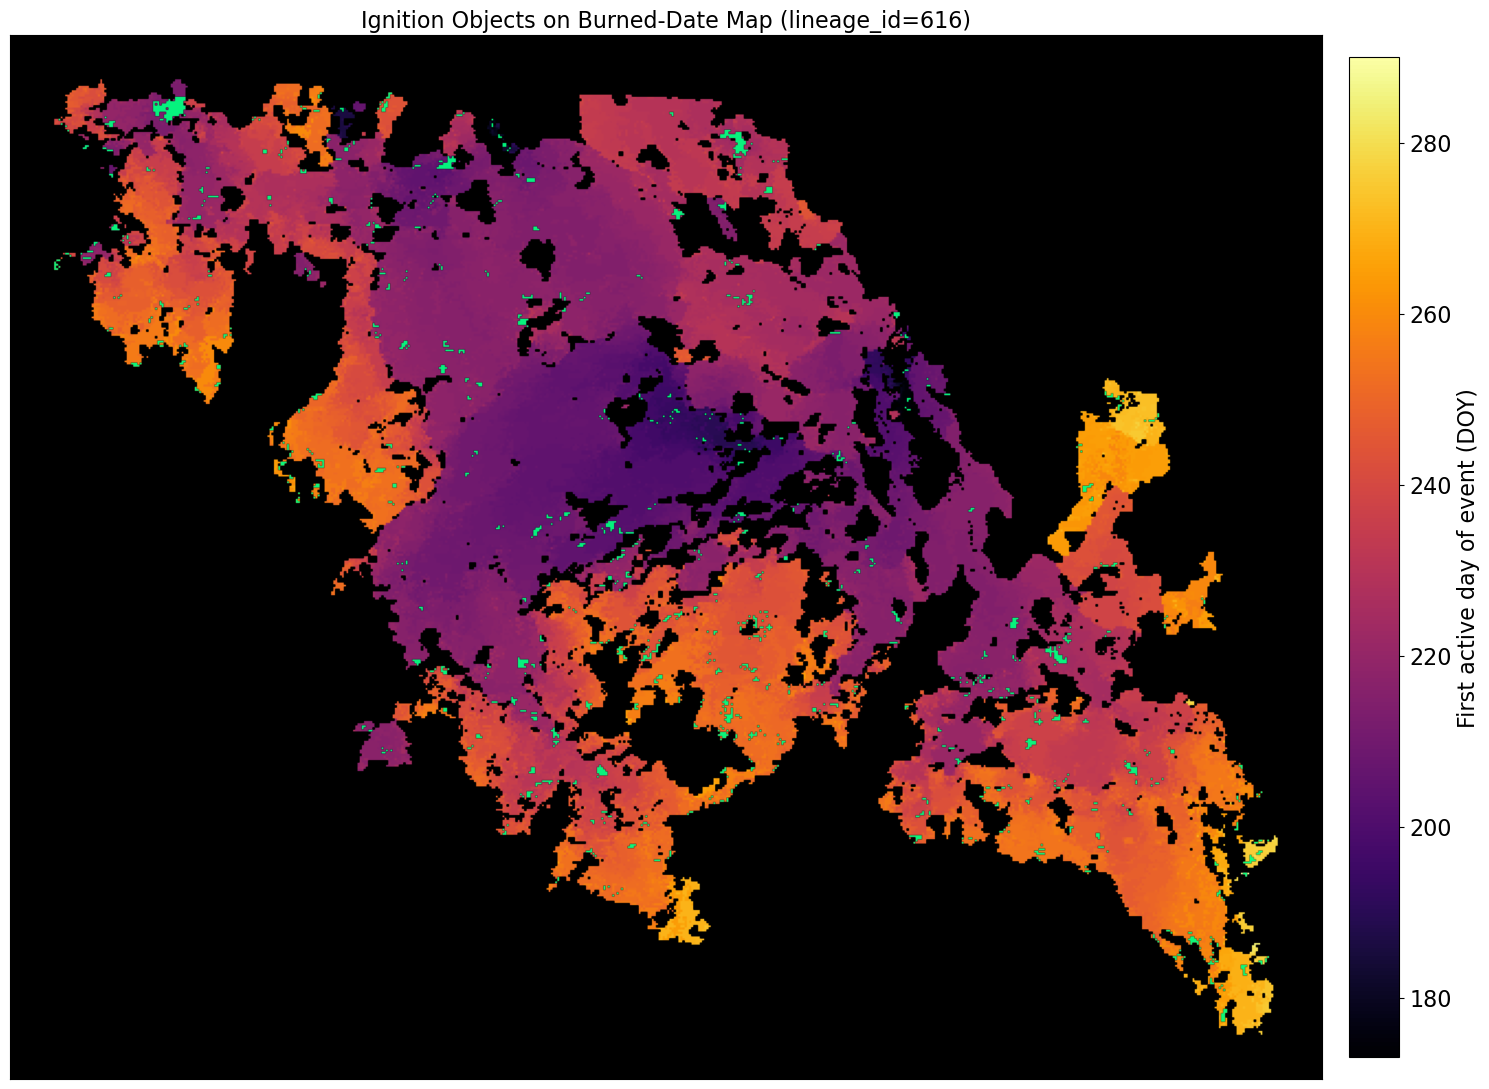

In [19]:
fig, ax = plt.subplots(figsize=(15, 15))
ax.set_facecolor("black")
im = ax.imshow(burn_date, cmap="inferno", origin="lower")
ign_overlay = np.ma.masked_where(ign_map == 0, ign_map)
ax.imshow(ign_overlay, cmap="winter", origin="lower", alpha=0.95, vmin=0, vmax=1)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title(f"Ignition Objects on Burned-Date Map (lineage_id={lineage_id})",fontsize=16)
cbar = plt.colorbar(im, ax=ax, fraction=0.036, pad=0.02)
cbar.set_label("First active day of event (DOY)",fontsize=16)
cbar.ax.tick_params(labelsize=16)
plt.tight_layout()
plt.show()